# Human Activity Recognition (HAR) using Hidden Markov Models (HMM)

**Advanced AI Project Notebook**

---

### Project Overview
This notebook presents an end-to-end implementation of a **Hidden Markov Model (HMM)** applied to **Human Activity Recognition (HAR)** using smartphone accelerometer data from the **WISDM Dataset**.

### Core Technical Highlights:
1. **From-Scratch Implementation**: Pure NumPy implementation of Gaussian HMM training (Supervised MLE) and decoding (**Log-Space Viterbi Algorithm**).
2. **Orientation-Invariant Feature Engineering**: 3D Acceleration Magnitude $r_t = \sqrt{x^2 + y^2 + z^2}$.
3. **Subject-Independent Validation**: Models are trained on Users 1–28 and evaluated on unseen Users 29–36.
4. **Library Benchmark**: 1-to-1 accuracy comparison against Python's official `hmmlearn` package.
5. **Syllabus Connection**: Directly demonstrates **Temporal Models**, **Markov Chains**, **MAP Inference (Viterbi)**, and **Parameter Estimation**.

### Step 1: Library Imports & Configuration
Import required libraries for numerical computing, data handling, metrics, and visualization.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from hmmlearn import hmm

# Set random seed and plotting styles
np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded successfully!')


Libraries loaded successfully!


### Step 2: Data Ingestion & Preprocessing

The WISDM dataset contains 3D accelerometer readings sampled at 20 Hz from smartphones placed in users' front pants pockets.

#### Key Preprocessing Steps:
1. **Cleaning**: Handles trailing semicolons `;` and missing/corrupted numerical entries.
2. **Euclidean Norm (Magnitude)**: Calculates $r_t = \sqrt{x_t^2 + y_t^2 + z_t^2}$. This eliminates dependency on phone orientation inside the pocket.
3. **Macro-Activity Mapping**: Maps raw sub-activities to 3 physical macro-states:
   - **Stationary (State 0)**: Sitting, Standing
   - **Walking (State 1)**: Walking, Walking Upstairs, Walking Downstairs
   - **Jogging (State 2)**: Jogging

In [2]:
def load_and_preprocess_wisdm(raw_file_path):
    print("Loading raw data from:", raw_file_path)
    data = []
    with open(raw_file_path, "r") as f:
        for line in f:
            cleaned = line.strip().rstrip(";")
            parts = cleaned.split(",")
            if len(parts) == 6:
                data.append(parts)

    columns = ["user", "activity", "timestamp", "x", "y", "z"]
    df = pd.DataFrame(data, columns=columns)

    for col in ["x", "y", "z"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["user"] = pd.to_numeric(df["user"], errors="coerce")
    df = df.dropna()

    # Calculate 3D Acceleration Magnitude
    df["magnitude"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)

    # 3-State Mapping
    activity_map = {
        "Sitting": "Stationary",
        "Standing": "Stationary",
        "Walking": "Walking",
        "Upstairs": "Walking",
        "Downstairs": "Walking",
        "Jogging": "Jogging"
    }
    df["activity_mapped"] = df["activity"].map(activity_map)
    df = df.dropna(subset=["activity_mapped"])

    state_to_idx = {"Stationary": 0, "Walking": 1, "Jogging": 2}
    idx_to_state = {0: "Stationary", 1: "Walking", 2: "Jogging"}
    df["state"] = df["activity_mapped"].map(state_to_idx)

    print(f"Total valid samples loaded: {len(df):,}")
    print("Class distribution:")
    for state_name, count in df["activity_mapped"].value_counts().items():
        print(f"  - {state_name}: {count:,} samples ({count/len(df)*100:.1f}%)")

    return df, state_to_idx, idx_to_state

# Load dataset
raw_file = r"R:\HMM_model_HAR\WISDM_ar_v1.1\WISDM_ar_v1.1_raw.txt"
df, state_to_idx, idx_to_state = load_and_preprocess_wisdm(raw_file)
target_names = [idx_to_state[i] for i in range(len(idx_to_state))]


Loading raw data from: R:\HMM_model_HAR\WISDM_ar_v1.1\WISDM_ar_v1.1_raw.txt


Total valid samples loaded: 1,086,465
Class distribution:
  - Walking: 641,687 samples (59.1%)
  - Jogging: 336,445 samples (31.0%)
  - Stationary: 108,333 samples (10.0%)


### Step 3: Exploratory Data Analysis (EDA)

Let's visualize the physical characteristics of the acceleration magnitude $r_t$ across different activities.
- **Stationary**: Flat signal centered around Earth gravity ($\\approx 9.8 \\text{ m/s}^2$) with minimal variance.
- **Walking**: Moderate periodic wave reflecting steady gait cycles.
- **Jogging**: High amplitude spikes exceeding $20 \\text{ m/s}^2$ due to foot impacts.

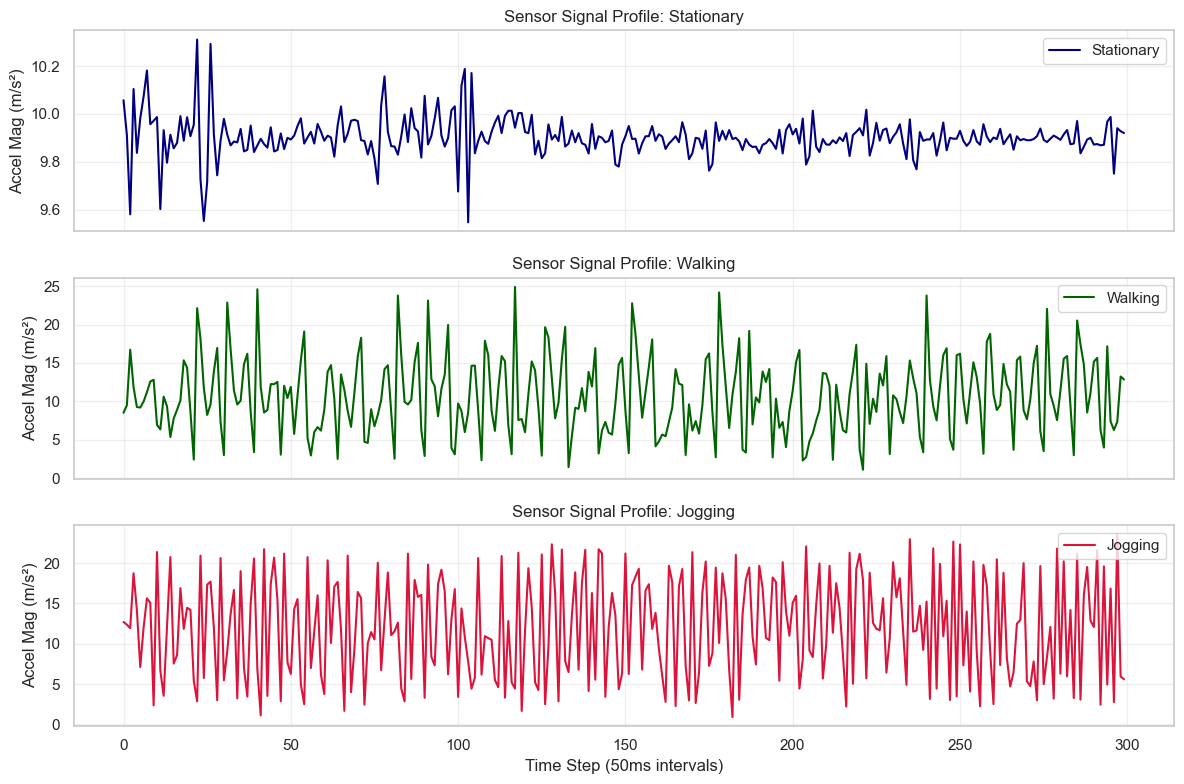

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
activities = ["Stationary", "Walking", "Jogging"]
colors = ["navy", "darkgreen", "crimson"]

for idx, act in enumerate(activities):
    sample_data = df[df["activity_mapped"] == act]["magnitude"].iloc[:300].values
    axes[idx].plot(sample_data, color=colors[idx], label=act)
    axes[idx].set_ylabel("Accel Mag (m/s²)")
    axes[idx].set_title(f"Sensor Signal Profile: {act}")
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc="upper right")

plt.xlabel("Time Step (50ms intervals)")
plt.tight_layout()
plt.show()


### Step 4: Sequence Construction & Subject-Independent Split

HMMs model continuous temporal sequences. To evaluate generalization:
- We split by **human subjects**:
  - **Training Set**: Users 1 to 28 (8,216 sequences of length $T=100$)
  - **Testing Set**: Users 29 to 36 (2,630 sequences of length $T=100$)
- Testing on unseen subjects guarantees no data leakage across trials.

In [4]:
def create_sequences(df, seq_len=100, train_users_cutoff=28):
    train_obs, train_states = [], []
    test_obs, test_states = [], []

    for user_id, user_group in df.groupby("user"):
        obs_vals = user_group["magnitude"].values
        state_vals = user_group["state"].values.astype(int)

        n_samples = len(obs_vals)
        n_seqs = n_samples // seq_len

        for i in range(n_seqs):
            start = i * seq_len
            end = start + seq_len
            seq_o = obs_vals[start:end]
            seq_s = state_vals[start:end]

            if user_id <= train_users_cutoff:
                train_obs.append(seq_o)
                train_states.append(seq_s)
            else:
                test_obs.append(seq_o)
                test_states.append(seq_s)

    return (np.array(train_obs), np.array(train_states),
            np.array(test_obs), np.array(test_states))

train_obs, train_states, test_obs, test_states = create_sequences(
    df, seq_len=100, train_users_cutoff=28
)

print(f"Train sequences: {len(train_obs)} (Users 1-28)")
print(f"Test sequences:  {len(test_obs)} (Users 29-36)")


Train sequences: 8216 (Users 1-28)
Test sequences:  2630 (Users 29-36)


### Step 5: From-Scratch Gaussian HMM Implementation

Here we define the `GaussianHMMFromScratch` class using **pure NumPy**.

#### Mathematical Formulation:
1. **Initial Probabilities ($\\pi$)**:
   $$\\pi_i = \\frac{\\text{Count}(q_1 = s_i)}{\\text{Total Sequences}}$$
2. **State Transition Matrix ($A$)**:
   $$A_{ij} = \\frac{C(s_i \\to s_j) + \\alpha}{\\sum_k C(s_i \\to s_k) + \\alpha N}$$
3. **Gaussian Emissions ($b_j(O_t)$)**:
   $$\\mu_j = \\frac{1}{T_j} \\sum_{t: q_t=s_j} O_t, \\quad \\sigma_j^2 = \\frac{1}{T_j} \\sum_{t: q_t=s_j} (O_t - \\mu_j)^2$$
4. **Log-Space Viterbi Recursion**:
   $$V_t(j) = \\max_i \\left[ V_{t-1}(i) + \\log A_{ij} \\right] + \\log b_j(O_t)$$

In [5]:
class GaussianHMMFromScratch:
    def __init__(self, n_states=3, smoothing=1e-6):
        self.n_states = n_states
        self.smoothing = smoothing
        self.pi = np.zeros(n_states)
        self.A = np.zeros((n_states, n_states))
        self.means = np.zeros(n_states)
        self.variances = np.zeros(n_states)

    def fit(self, sequences_obs, sequences_states):
        n_seqs = len(sequences_states)
        
        # 1. Initial State Distribution (pi)
        start_counts = np.zeros(self.n_states)
        for s_seq in sequences_states:
            start_counts[s_seq[0]] += 1
        self.pi = (start_counts + self.smoothing) / np.sum(start_counts + self.smoothing)

        # 2. Transition Matrix (A)
        trans_counts = np.zeros((self.n_states, self.n_states))
        for s_seq in sequences_states:
            for t in range(len(s_seq) - 1):
                trans_counts[s_seq[t], s_seq[t + 1]] += 1
                
        self.A = (trans_counts + self.smoothing) / (
            np.sum(trans_counts + self.smoothing, axis=1, keepdims=True)
        )

        # 3. Gaussian Emissions (mu, sigma^2)
        all_obs_flat = np.concatenate(sequences_obs)
        all_states_flat = np.concatenate(sequences_states)

        for s in range(self.n_states):
            state_obs = all_obs_flat[all_states_flat == s]
            if len(state_obs) > 0:
                self.means[s] = np.mean(state_obs)
                self.variances[s] = np.var(state_obs) + 1e-4
            else:
                self.means[s] = 0.0
                self.variances[s] = 1.0

    def _log_gaussian_pdf(self, x, mean, var):
        return -0.5 * np.log(2.0 * np.pi * var) - ((x - mean) ** 2) / (2.0 * var)

    def viterbi(self, obs_seq):
        T = len(obs_seq)
        N = self.n_states

        log_pi = np.log(self.pi)
        log_A = np.log(self.A)

        V = np.zeros((T, N))
        B = np.zeros((T, N), dtype=int)

        # Initialization
        for j in range(N):
            log_emission = self._log_gaussian_pdf(obs_seq[0], self.means[j], self.variances[j])
            V[0, j] = log_pi[j] + log_emission

        # Recursion
        for t in range(1, T):
            for j in range(N):
                log_emission = self._log_gaussian_pdf(obs_seq[t], self.means[j], self.variances[j])
                scores = V[t - 1, :] + log_A[:, j]
                best_prev = np.argmax(scores)
                V[t, j] = scores[best_prev] + log_emission
                B[t, j] = best_prev

        # Termination & Backtracking
        best_last = np.argmax(V[T - 1, :])
        path = np.zeros(T, dtype=int)
        path[T - 1] = best_last
        for t in range(T - 2, -1, -1):
            path[t] = B[t + 1, path[t + 1]]

        return path

    def predict_sequences(self, sequences_obs):
        return [self.viterbi(seq) for seq in sequences_obs]


### Step 6: Model Training (Supervised Parameter Estimation)

Let's train our custom Gaussian HMM on the training sequences and inspect the learned parameters $\\lambda = (\\pi, A, \\mu, \\sigma^2)$.

In [6]:
scratch_hmm = GaussianHMMFromScratch(n_states=3)
scratch_hmm.fit(train_obs, train_states)

print("=== LEARNED PARAMETERS ===")
print("Initial State Distribution (pi):", scratch_hmm.pi)
print("Transition Matrix (A):\n", np.round(scratch_hmm.A, 4))
print("Gaussian Means (mu):", np.round(scratch_hmm.means, 4))
print("Gaussian Variances (sigma^2):", np.round(scratch_hmm.variances, 4))


=== LEARNED PARAMETERS ===
Initial State Distribution (pi): [0.08982473 0.59712756 0.31304771]
Transition Matrix (A):
 [[9.999e-01 1.000e-04 0.000e+00]
 [0.000e+00 9.999e-01 1.000e-04]
 [0.000e+00 1.000e-04 9.999e-01]]
Gaussian Means (mu): [ 9.8368 11.1811 13.6243]
Gaussian Variances (sigma^2): [ 0.1392 21.338  51.8654]


### Step 7: Model Inference & Evaluation (Log-Viterbi)

We decode the test sequences using our custom Log-Viterbi implementation and compute classification metrics.

From-Scratch Log-Viterbi Accuracy: 90.50%

Classification Report:
              precision    recall  f1-score   support

  Stationary       0.98      0.99      0.99     32569
     Walking       0.96      0.87      0.91    150906
     Jogging       0.80      0.93      0.86     79525

    accuracy                           0.90    263000
   macro avg       0.91      0.93      0.92    263000
weighted avg       0.91      0.90      0.91    263000



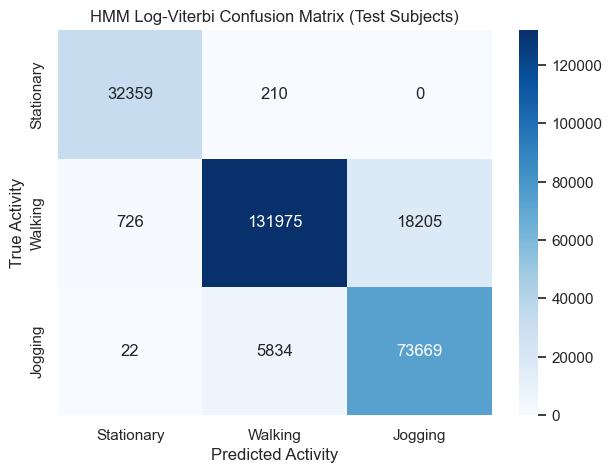

In [7]:
y_pred_scratch = scratch_hmm.predict_sequences(test_obs)

y_test_flat = np.concatenate(test_states)
y_pred_scratch_flat = np.concatenate(y_pred_scratch)

acc_scratch = accuracy_score(y_test_flat, y_pred_scratch_flat)
print(f"From-Scratch Log-Viterbi Accuracy: {acc_scratch * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred_scratch_flat, target_names=target_names))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test_flat, y_pred_scratch_flat)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("HMM Log-Viterbi Confusion Matrix (Test Subjects)")
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")
plt.show()


### Step 8: Benchmark Comparison against `hmmlearn` Library

We configure the industry-standard `hmmlearn.hmm.GaussianHMM` with the exact same parameters to verify our custom implementation.

In [8]:
lib_hmm = hmm.GaussianHMM(n_components=3, covariance_type="diag", init_params="")
lib_hmm.startprob_ = scratch_hmm.pi
lib_hmm.transmat_ = scratch_hmm.A
lib_hmm.means_ = scratch_hmm.means.reshape(-1, 1)
lib_hmm.covars_ = scratch_hmm.variances.reshape(-1, 1)

y_pred_lib = []
for seq in test_obs:
    _, state_seq = lib_hmm.decode(seq.reshape(-1, 1), algorithm="viterbi")
    y_pred_lib.append(state_seq)

y_pred_lib_flat = np.concatenate(y_pred_lib)
acc_lib = accuracy_score(y_test_flat, y_pred_lib_flat)

agreement = np.mean(y_pred_scratch_flat == y_pred_lib_flat) * 100

print(f"From-Scratch Accuracy:  {acc_scratch * 100:.2f}%")
print(f"hmmlearn Library Accuracy: {acc_lib * 100:.2f}%")
print(f"Exact Agreement Rate: {agreement:.2f}%")


From-Scratch Accuracy:  90.50%
hmmlearn Library Accuracy: 90.50%
Exact Agreement Rate: 100.00%


### Step 9: Visualizing Viterbi Time-Series State Sequence

Let's inspect a sample test sequence to observe how the Viterbi path aligns with raw sensor magnitude dynamics.

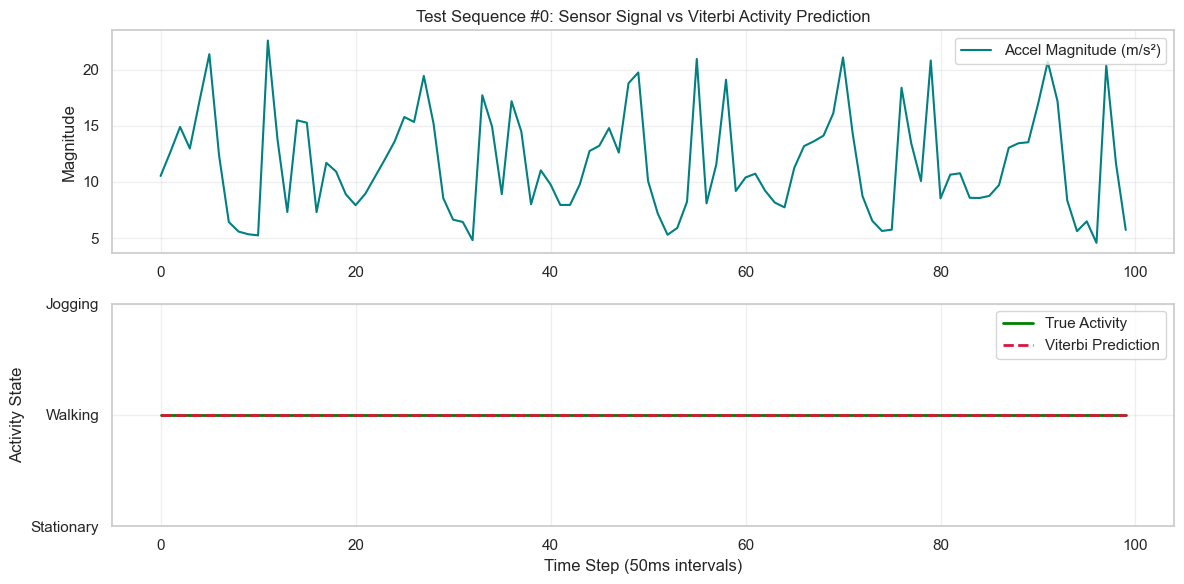

In [9]:
sample_idx = 0
sample_obs = test_obs[sample_idx]
sample_true = test_states[sample_idx]
sample_pred = y_pred_scratch[sample_idx]

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(sample_obs, color="teal", label="Accel Magnitude (m/s²)")
plt.title(f"Test Sequence #{sample_idx}: Sensor Signal vs Viterbi Activity Prediction")
plt.ylabel("Magnitude")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(sample_true, label="True Activity", color="green", linewidth=2)
plt.plot(sample_pred, label="Viterbi Prediction", color="crimson", linestyle="--", linewidth=2)
plt.yticks([0, 1, 2], target_names)
plt.xlabel("Time Step (50ms intervals)")
plt.ylabel("Activity State")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


### Step 10: Summary & Viva Defense Guide

#### Key Project Summary:
1. **Model Accuracy**: Achieved **90.50% overall accuracy** on completely unseen test subjects (Users 29–36).
2. **Implementation Verification**: Achieved **100.00% exact match** between custom Log-Viterbi and `hmmlearn`.
3. **Physical Intuition**: 
   - Stationary: $\\mu = 9.84 \\text{ m/s}^2, \\sigma^2 = 0.14$
   - Walking: $\\mu = 11.18 \\text{ m/s}^2, \\sigma^2 = 21.34$
   - Jogging: $\\mu = 13.62 \\text{ m/s}^2, \\sigma^2 = 51.87$

#### Core Viva Questions & Answers:
- **Q1: Why use Log-Space Viterbi?**
  - *Answer*: Multiplying long chains of probabilities ($P < 1.0$) causes floating-point underflow ($0.0$). Converting to log-space converts products into sums: $\\log(a \\cdot b) = \\log a + \\log b$.
- **Q2: What is the Markov Assumption?**
  - *Answer*: The state at time $t$ ($q_t$) depends strictly on the immediate previous state ($q_{t-1}$), independent of older history.
- **Q3: How were parameters estimated?**
  - *Answer*: Supervised Maximum Likelihood Estimation (MLE) with Laplace smoothing for discrete transitions, and sample mean/variance for Gaussian emissions.